# Neural Network 
## Mushroom Dataset

#### Final Project: DSC 345/445
#### Victoria Burke and Rebecca Henzig

### Data setup procedure

note: the neural network performed so well on a 20% holdout test set that I increased the test set size in this setup code to 30% to validate that this exceptional performance was maintained with a greater number of unseen samples.  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv('../data/cleaned_mushrooms.csv')

# train test split
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 123, stratify = y
)

# One-hot encoding
cat_cols = X.columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

onehot_feature_names = preprocessor.get_feature_names_out()
print(onehot_feature_names)


['cat__cap-shape_b' 'cat__cap-shape_c' 'cat__cap-shape_f'
 'cat__cap-shape_k' 'cat__cap-shape_s' 'cat__cap-shape_x'
 'cat__cap-surface_f' 'cat__cap-surface_g' 'cat__cap-surface_s'
 'cat__cap-surface_y' 'cat__cap-color_b' 'cat__cap-color_c'
 'cat__cap-color_e' 'cat__cap-color_g' 'cat__cap-color_n'
 'cat__cap-color_p' 'cat__cap-color_r' 'cat__cap-color_u'
 'cat__cap-color_w' 'cat__cap-color_y' 'cat__bruises_f' 'cat__bruises_t'
 'cat__odor_a' 'cat__odor_c' 'cat__odor_f' 'cat__odor_l' 'cat__odor_m'
 'cat__odor_n' 'cat__odor_p' 'cat__odor_s' 'cat__odor_y'
 'cat__gill-attachment_a' 'cat__gill-attachment_f' 'cat__gill-spacing_c'
 'cat__gill-spacing_w' 'cat__gill-size_b' 'cat__gill-size_n'
 'cat__gill-color_b' 'cat__gill-color_e' 'cat__gill-color_g'
 'cat__gill-color_h' 'cat__gill-color_k' 'cat__gill-color_n'
 'cat__gill-color_o' 'cat__gill-color_p' 'cat__gill-color_r'
 'cat__gill-color_u' 'cat__gill-color_w' 'cat__gill-color_y'
 'cat__stalk-shape_e' 'cat__stalk-shape_t' 'cat__stalk-root_?'
 '

Re-encode class labels as 0 and 1: "Poisonous" serves as the positive class. We need to tune our neural network to maximize recall; our goal is to correctly identify as many positive samples as possible (to avoid consuming deadly mushrooms, obviously).

In [2]:
labels = {'e': 0, 'p': 1}
y_train = y_train.map(labels)
y_test  = y_test.map(labels)

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

This following code was needed in my neural network homework assignment in addition to the random seed for reproducing results, so I will use it again here.

In [3]:
import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '12'

Because the dataset is small and relatively simple, we will build the neural network with Keras for simplicity as we did in class (rather than messing with TensorFlow directly, or PyTorch).

In [4]:
import keras
from keras import layers
import tensorflow as tf # still need to import tf to use their confusion matrix function 

randstate = 528491
keras.utils.set_random_seed(randstate)

In [5]:
X_train.shape[1]

117

The input layer matches the number of features (117 in the one-hot encoded data). 

Since this is a binary classification problem, the output layer will use a sigmoid activation function and the loss should be binary cross-entropy loss.

### Preliminary, simple model

As a baseline, this is a simple neural network with only input and output layers. It uses stochastic gradient descent as the optimizer. 

The metrics we use for evaluation are accuracy, recall (sensitivity), and specificity at sensitivity. Specificity at sensitivity is a Keras function that computes best specificity where sensitivity is >= specified value. Since it is essential that our model does not misclassify poisonous mushrooms as edible, we will start by setting sensitivity to 1 (100% of poisonous mushrooms predicted as such) and evaluate at that point.

In [6]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
              optimizer = 'SGD',
              metrics = ['accuracy', 'recall', tf.keras.metrics.SpecificityAtSensitivity(sensitivity=1)])

model.fit(X_train, y_train, batch_size=5, epochs=100)

Epoch 1/100


E0000 00:00:1780986011.022774 37030849 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


1138/1138 ━━━━━━━━━━━━━━━━━━━━ 1s 565us/step - accuracy: 0.9085 - loss: 0.2912 - recall: 0.8621 - specificity_at_sensitivity: 0.2638
Epoch 2/100
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 1s 558us/step - accuracy: 0.9694 - loss: 0.1424 - recall: 0.9548 - specificity_at_sensitivity: 0.6540
Epoch 3/100
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 1s 564us/step - accuracy: 0.9784 - loss: 0.1078 - recall: 0.9715 - specificity_at_sensitivity: 0.8248
Epoch 4/100
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 1s 503us/step - accuracy: 0.9807 - loss: 0.0900 - recall: 0.9734 - specificity_at_sensitivity: 0.8958
Epoch 5/100
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 1s 516us/step - accuracy: 0.9819 - loss: 0.0785 - recall: 0.9745 - specificity_at_sensitivity: 0.9175
Epoch 6/100
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 1s 532us/step - accuracy: 0.9836 - loss: 0.0701 - recall: 0.9752 - specificity_at_sensitivity: 0.9195
Epoch 7/100
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 1s 502us/step - accuracy: 0.9845 - loss: 0.0637 - recall: 0.9767 - specificity_at_sensitivity: 0.92

Even with this very basic neural network, which is essentially modeling a linear pattern since there are no activation layers, accuracy and recall are extremely high on the training set (almost perfect). We will validate on the test set:

In [7]:
model.evaluate(X_test, y_test)

 1/77 ━━━━━━━━━━━━━━━━━━━━ 13s 178ms/step - accuracy: 1.0000 - loss: 0.0043 - recall: 1.0000 - specificity_at_sensitivity: 1.0000

E0000 00:00:1780986070.593784 37030849 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 643us/step - accuracy: 0.9979 - loss: 0.0108 - recall: 0.9957 - specificity_at_sensitivity: 1.0000 


[0.010750343091785908, 0.9979491233825684, 0.9957447052001953, 1.0]

This simple neural network has very high accuracy and recall on the test set also. We will examine a confusion matrix to see the exact breakdown:

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 439us/step
tf.Tensor(
[[1263    0]
 [   5 1170]], shape=(2, 2), dtype=int32)


<Axes: >

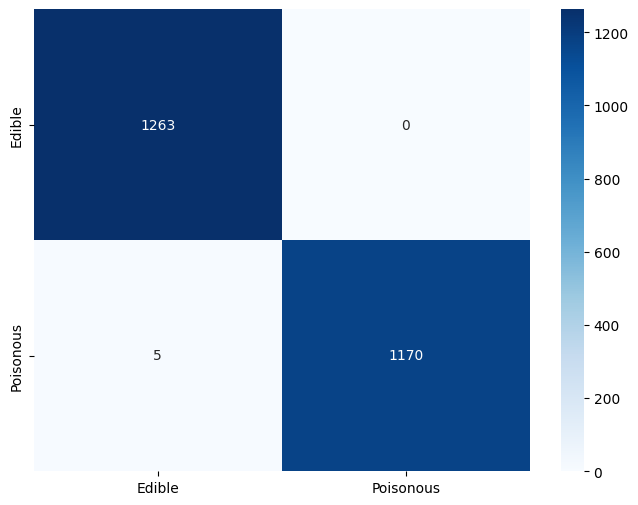

In [8]:
predictions = model.predict(X_test) # Probabilities 
predictions = (predictions > 0.5).astype(int).flatten() # Predictions 0 or 1 at 50% threshold
confusion_matrix = tf.math.confusion_matrix(
    y_test,
    predictions,
    num_classes=None,
    weights=None,
    dtype=tf.dtypes.int32,
    name=None
)

class_names = ['Edible', 'Poisonous']

print(confusion_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names, 
    yticklabels=class_names
)

The confusion matrix shows very high sensitivity/recall and specificity. No poisonous mushrooms were misclassified as edible, which is fantastic. There were, however, 5 edible mushrooms misclassified as poisonous. The practical cost of this misclassification is much less than the other way around, so this could be acceptable in a final model. 

We will still modify the neural network to see if this small bit of error can be improved, and also to examine how the model results change when we add additonal layers. 

### Adding activation layers for non-linearity

We added a single ReLU activation layer to introduce nonlinearity into the model predictions:

In [9]:
keras.utils.set_random_seed(randstate)

model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(200, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
              optimizer = 'SGD',
              metrics = ['accuracy', 'recall', tf.keras.metrics.SpecificityAtSensitivity(sensitivity=1)])

model.fit(X_train, y_train, batch_size=5, epochs=100)

Epoch 1/100
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 1s 523us/step - accuracy: 0.9504 - loss: 0.1880 - recall: 0.9259 - specificity_at_sensitivity_1: 0.5701
Epoch 2/100
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 1s 578us/step - accuracy: 0.9873 - loss: 0.0569 - recall: 0.9785 - specificity_at_sensitivity_1: 0.8428
Epoch 3/100
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 1s 539us/step - accuracy: 0.9953 - loss: 0.0338 - recall: 0.9909 - specificity_at_sensitivity_1: 0.8964
Epoch 4/100
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 1s 617us/step - accuracy: 0.9979 - loss: 0.0234 - recall: 0.9956 - specificity_at_sensitivity_1: 0.9338
Epoch 5/100
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 1s 542us/step - accuracy: 0.9984 - loss: 0.0176 - recall: 0.9967 - specificity_at_sensitivity_1: 0.9514
Epoch 6/100
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 1s 541us/step - accuracy: 0.9989 - loss: 0.0139 - recall: 0.9978 - specificity_at_sensitivity_1: 0.9732
Epoch 7/100
1138/1138 ━━━━━━━━━━━━━━━━━━━━ 1s 567us/step - accuracy: 0.9991 - loss: 0.0114 - recall: 0.9982 - specific

Adding the single hidden layer increased accuracy and recall on the training set in the final iteration to 100%. Note that it took 99 epochs to reach 100% recall. Now the test set:

In [10]:
model.evaluate(X_test, y_test)

 1/77 ━━━━━━━━━━━━━━━━━━━━ 13s 175ms/step - accuracy: 1.0000 - loss: 1.2858e-04 - recall: 1.0000 - specificity_at_sensitivity_1: 1.0000

E0000 00:00:1780986130.331204 37030849 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 679us/step - accuracy: 1.0000 - loss: 4.7061e-04 - recall: 1.0000 - specificity_at_sensitivity_1: 1.0000 


[0.0004706137697212398, 1.0, 1.0, 1.0]

Adding the single hidden layer gives 100% accuracy and recall on the test set. We will look at a confusion matrix to summarize this:

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step
tf.Tensor(
[[1263    0]
 [   0 1175]], shape=(2, 2), dtype=int32)


<Axes: >

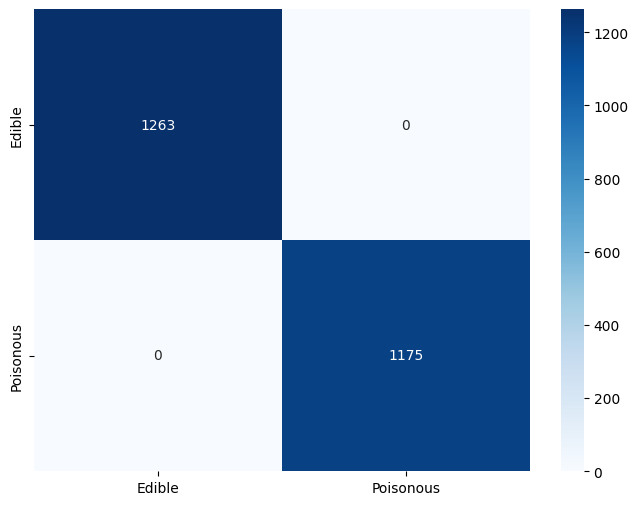

In [11]:
predictions = model.predict(X_test) # Probabilities 
predictions = (predictions > 0.5).astype(int).flatten() # Predictions 0 or 1 at 50% threshold
confusion_matrix = tf.math.confusion_matrix(
    y_test,
    predictions,
    num_classes=None,
    weights=None,
    dtype=tf.dtypes.int32,
    name=None
)

class_names = ['Edible', 'Poisonous']

print(confusion_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names, 
    yticklabels=class_names
)



The confusion matrix shows that the second model has 100% specificity as well as the 100% sensitivity previously discussed. There are 0 misclassifications in the test set for either class, showing the neural network is equally able to distinguish edible and poisonous mushrooms without needing us to adjust it to prioritize recall/sensitivity. If the model classifies an unknown mushroom as edible or poisonous, we can be nearly certain that the prediction is correct. 

This neural network performs exceptionally well and no modifications are needed. Adding a single ReLU activation layer was able to eliminate the (already tiny) amount of misclassification in the prior model.


### Model interpretability

A downside of neural networks is that they are the most complex model covered in this class and are difficult to explain. They essentially function as a black box. To try to decode what the neural network considers significant for classification, we will use SHAP to investigate feature importance. 

The shap package has a function called DeepExplainer specifically for deep learning neural networks, but since our neural network is very simple and not really a "deep learning" model, we chose to use the standard ``shap.Explainer`` function.

Since all predictors are categorical, many with multiple classes, it is not possible to interpret the standard SHAP summary plot. Instead, we will just look at the bar plot of absolute values of SHAP values to determine which features contribute most to classification.

PermutationExplainer explainer: 2439it [01:26, 25.49it/s]                          
/var/folders/mh/zg3b2zr94032k7gnp8s2d0n80000gn/T/ipykernel_31265/1370403269.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type = "bar", feature_names=onehot_feature_names)


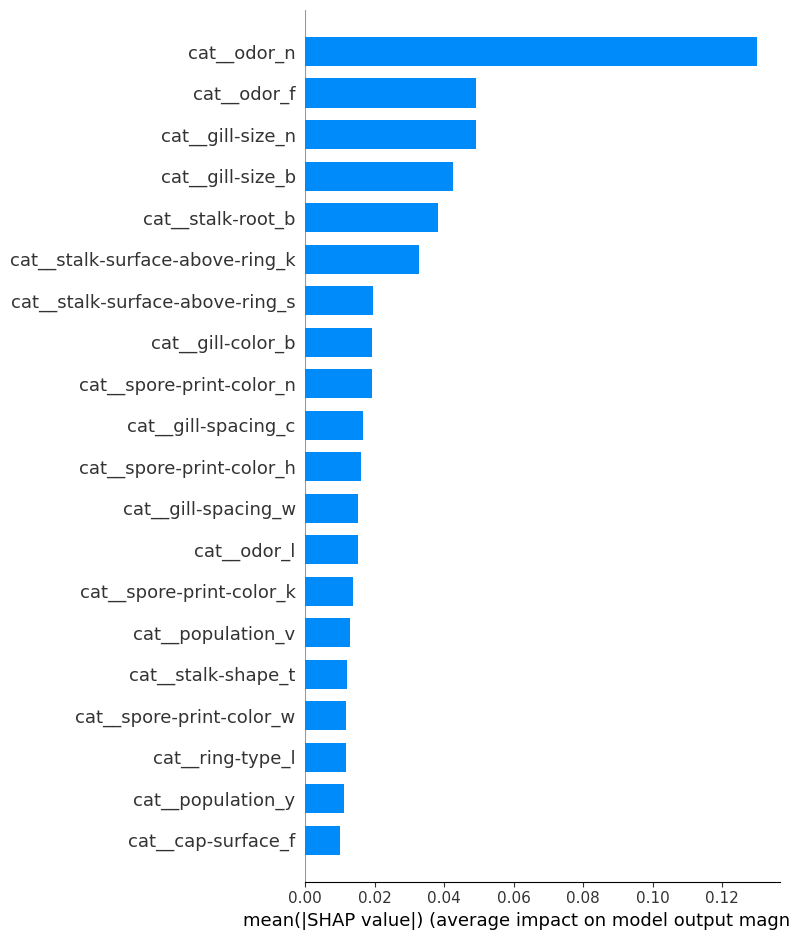

In [12]:
import shap

background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]
shap_explainer = shap.Explainer(model, background)
shap_values = shap_explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type = "bar", feature_names=onehot_feature_names)



By far the most important feature for classification in the neural network is odor. Gill size, stalk root, stalk surface above ring, gill color, and spore print color are also notable contributors.

A variety of variables appear on the SHAP plot, suggesting there are clues from several different physical characteristics of the mushrooms that can be used to group mushrooms into poisonous or edible categories.

### Conclusions

A relatively very simple neural network, with one ReLU activation layer and one sigmoid output layer, was exceptionally effective at correctly classifying poisonous and edible mushrooms. It did not misclassify ANY of the poisonous mushrooms as edible, and as a bonus, it didn't even misclassify any of the edible mushrooms as poisonous either. We can place trust in the predictions of the neural network, so it succeeds at our originally stated goal.

A neural network may be overkill for this simplistic of a dataset with such rigid, separable boundaries between classes. This is indicated by the high performance of a trivial neural network with no activation layers on the data. There are not complex nonlinear boundaries between classes that would necessitate using a neural network over another type of model. A simpler model may be able to replicate this performance with less computational resources and improved explainability. Explainability is important in this classification problem because feature importance identifies the most dangerous signifiers of poisonous mushrooms to look out for in the field when examining new species. Neural networks by definition struggle with this, so that is a limitation of this strategy.